<a href="https://colab.research.google.com/github/reedlm11/INFO648/blob/main/Final_Project_INFO648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                  Final Project

                                  INFO 648

                                  6/30/2026

                                  By: Sarah Hampton and Lae'sha Reed


#**Phase 1: Business Understanding**

The U.S. Department of Economic Development wants to allocate funding to areas that are expected to experience population growth. Our objective is to predict which census tracts in the Pacific region will gain population, identify the factors associated with growth, and use those patterns to forecast growth from 2020 to 2030.

Success Criterion

Our goal is to build a classification model that outperforms the majority-class baseline while achieving a strong AUC and balanced precision and recall.

Target Variable

The target variable is whether a census tract gained population between 2010 and 2020. A tract is labeled as "grew" if its population growth is greater than 0%, and "did not grow" otherwise.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#**Phase 2: Data Understanding**

Pacific Region

Our analysis focuses on the Pacific Census Division, which includes Alaska, California, Hawaii, Oregon, and Washington. First we'll beging by filtering the national census dataset to include only census tracts from these five states

In [53]:
raw = pd.read_csv("student_tracts_raw.csv")
region_counts = pd.read_csv("region_tract_counts.csv")
data_dict = pd.read_csv("data_dictionary.csv")
forecast = pd.read_csv("forecast_tracts_2020.csv")

pacific_states = ["Alaska", "California", "Hawaii", "Oregon", "Washington"]

pacific = raw[raw["STATE"].isin(pacific_states)].copy()

pacific.shape

(10867, 49)

#Verify the Pacific Region Filter

In [54]:
pacific["STATE"].value_counts()

,count
STATE,
California,8057
Washington,1458
Oregon,834
Hawaii,351
Alaska,167


#Examine Dataset Structure

In [55]:
pacific.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10867 entries, 1181 to 71031
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   GISJOIN                  10867 non-null  object 
 1   STATE                    10867 non-null  object 
 2   STATEA                   10867 non-null  int64  
 3   COUNTY                   10867 non-null  object 
 4   COUNTYA                  10867 non-null  int64  
 5   TRACTA                   10867 non-null  int64  
 6   pop_total_2010           10867 non-null  int64  
 7   housing_occupied_2010    10867 non-null  int64  
 8   housing_vacant_2010      10867 non-null  int64  
 9   housing_owner_occ_2010   10867 non-null  int64  
 10  housing_renter_occ_2010  10867 non-null  int64  
 11  age_under5_2010          10867 non-null  int64  
 12  age_5to9_2010            10867 non-null  int64  
 13  age_10to14_2010          10867 non-null  int64  
 14  age_15to17_2010         

In [56]:
pacific.describe().T

,count,mean,std,min,25%,50%,75%,max
STATEA,10867.0,15.221220,17.557049,2.0,6.000000,6.000000,6.000000,53.000000
COUNTYA,10867.0,50.981964,29.173517,1.0,37.000000,51.000000,71.000000,290.000000
TRACTA,10867.0,196604.855894,272777.180289,100.0,8130.500000,42009.000000,360350.000000,992201.000000
pop_total_2010,10867.0,4590.052636,1969.022161,0.0,3324.000000,4403.000000,5658.500000,37452.000000
housing_occupied_2010,10867.0,1603.930063,703.965526,0.0,1128.000000,1527.000000,2006.000000,8382.000000
housing_vacant_2010,10867.0,150.721174,229.025781,0.0,58.000000,96.000000,159.000000,6403.000000
housing_owner_occ_2010,10867.0,927.507408,562.251593,0.0,525.000000,863.000000,1250.000000,5054.000000
housing_renter_occ_2010,10867.0,676.422656,487.686231,0.0,313.000000,572.000000,917.000000,5971.000000
age_under5_2010,10867.0,308.268059,195.894408,0.0,179.000000,276.000000,398.000000,4855.000000
age_5to9_2010,10867.0,304.332198,187.925807,0.0,181.000000,277.000000,393.000000,2639.000000


#Check for Missing Values

In [57]:
pacific.isna().sum().sort_values(ascending=False).head(15)

,0
density_perkm2,65
settlement_type,65
land_area_sqkm,62
STATE,0
COUNTYA,0
TRACTA,0
STATEA,0
COUNTY,0
housing_vacant_2010,0
housing_owner_occ_2010,0


#Initial Observations

- After filtering the national dataset, the Pacific region contains 10,867 census tracts across California, Washington, Oregon, Hawaii, and Alaska.
- The dataset consists primarily of numeric census count variables, with STATE and settlement_type being categorical features.
- Most variables are complete, with missing values only in land_area_sqkm, density_perkm2, and settlement_type. These missing values are consistent with the water-only census tracts described in the project instructions and will be addressed during data prep.
- The summary stats show considerable variation in population, housing, and demographic characteristics across census tracts, suggesting there is meaningful diversity for clustering and classification.

#**Phase 3: Data Preparation**


In this phase, we prepare the dataset for modeling by creating the target variable, cleaning records with undefined calculations, engineering features, and splitting the data into training and testing sets.

In [58]:
pacific["growth_pct"] = (
    (pacific["pop_total_2020"] - pacific["pop_total_2010"])
    / pacific["pop_total_2010"]
) * 100

pacific["growth_pct"].describe()

,growth_pct
count,1.079700e+04
mean,inf
std,NaN
min,-1.000000e+02
25%,-2.740304e-01
50%,4.321442e+00
75%,9.942085e+00
max,inf


In [59]:
print((pacific["pop_total_2010"] == 0).sum())

84


In [60]:
pacific["pop_total_2010"].describe()

,pop_total_2010
count,10867.000000
mean,4590.052636
std,1969.022161
min,0.000000
25%,3324.000000
50%,4403.000000
75%,5658.500000
max,37452.000000


In [61]:
pacific = pacific[pacific["pop_total_2010"] > 0].copy()

pacific.shape

(10783, 50)

In [62]:
pacific["growth_pct"].describe()

,growth_pct
count,10783.000000
mean,8.167046
std,44.476159
min,-100.000000
25%,-0.280809
50%,4.303123
75%,9.903960
max,2900.000000


In [63]:
pacific["grew"] = (pacific["growth_pct"] > 0).astype(int)

pacific["grew"].value_counts()

,count
grew,
1,7925
0,2858


#Target Variable and Class Balance

The target variable, grew, was created by labeling census tracts with positive population growth between 2010 and 2020 as 1 and tracts with no growth or population loss as 0.

After removing tracts with a 2010 population of zero, the dataset contains 10,783 census tracts. Approximately 73.5% of tracts experienced population growth, while 26.5% did not. Although the classes are not perfectly balanced, both classes are well represented for classification.

In [64]:
pacific[
    pacific["land_area_sqkm"].isna() |
    pacific["density_perkm2"].isna() |
    pacific["settlement_type"].isna()
][["STATE", "COUNTY", "TRACTA", "land_area_sqkm", "density_perkm2", "settlement_type"]].head(10)

,STATE,COUNTY,TRACTA,land_area_sqkm,density_perkm2,settlement_type


In [65]:
pacific[["land_area_sqkm", "density_perkm2", "settlement_type"]].isna().sum()

,0
land_area_sqkm,0
density_perkm2,0
settlement_type,0


#Data Cleaning

To prep the dataset for modeling, we removed census tracts with a 2010 population of zero because population growth could not be calculated for those observations. After removing these tracts, there were no remaining missing values in land_area_sqkm, density_perkm2, or settlement_type. This indicates that the missing values were associated with the zero-population tracts and no additional records needed to be removed.

In [66]:
list(pacific.columns)

['GISJOIN',
 'STATE',
 'STATEA',
 'COUNTY',
 'COUNTYA',
 'TRACTA',
 'pop_total_2010',
 'housing_occupied_2010',
 'housing_vacant_2010',
 'housing_owner_occ_2010',
 'housing_renter_occ_2010',
 'age_under5_2010',
 'age_5to9_2010',
 'age_10to14_2010',
 'age_15to17_2010',
 'age_18to19_2010',
 'age_20_2010',
 'age_21_2010',
 'age_22to24_2010',
 'age_25to29_2010',
 'age_30to34_2010',
 'age_35to39_2010',
 'age_40to44_2010',
 'age_45to49_2010',
 'age_50to54_2010',
 'age_55to59_2010',
 'age_60to61_2010',
 'age_62to64_2010',
 'age_65to69_2010',
 'age_70to74_2010',
 'age_75to79_2010',
 'age_80to84_2010',
 'age_85plus_2010',
 'race_nhwhite_2010',
 'race_nhblack_2010',
 'race_nhaian_2010',
 'race_nhapi_2010',
 'race_nhother_2010',
 'race_nhtwo_2010',
 'race_hispwhite_2010',
 'race_hispblack_2010',
 'race_hispaian_2010',
 'race_hispapi_2010',
 'race_hispother_2010',
 'race_hisptwo_2010',
 'pop_total_2020',
 'land_area_sqkm',
 'density_perkm2',
 'settlement_type',
 'growth_pct',
 'grew']

In [67]:
# Total housing units
pacific["housing_total_2010"] = (
    pacific["housing_occupied_2010"] +
    pacific["housing_vacant_2010"]
)

# Housing percentages
pacific["pct_vacant"] = (
    pacific["housing_vacant_2010"] /
    pacific["housing_total_2010"]
)

pacific["pct_owner_occ"] = (
    pacific["housing_owner_occ_2010"] /
    pacific["housing_total_2010"]
)

pacific["pct_renter_occ"] = (
    pacific["housing_renter_occ_2010"] /
    pacific["housing_total_2010"]
)

pacific[
    [
        "pct_vacant",
        "pct_owner_occ",
        "pct_renter_occ"
    ]
].describe()

,pct_vacant,pct_owner_occ,pct_renter_occ
count,10767.000000,10767.000000,10767.000000
mean,0.080435,0.529870,0.389695
std,0.084046,0.222684,0.214263
min,0.000000,0.000000,0.000000
25%,0.041770,0.370819,0.213046
50%,0.058934,0.555748,0.355915
75%,0.084750,0.707940,0.539597
max,1.000000,1.000000,1.000000


In [68]:
# All age columns
age_cols = [col for col in pacific.columns if col.startswith("age_") and col.endswith("_2010")]

# Convert age counts to percentages of total population
for col in age_cols:
    new_col = col.replace("age_", "pct_age_")
    new_col = new_col.replace("_2010", "")
    pacific[new_col] = pacific[col] / pacific["pop_total_2010"]

# Check a few examples
pacific[
    [
        "pct_age_under5",
        "pct_age_25to29",
        "pct_age_65to69",
        "pct_age_85plus"
    ]
].describe()

,pct_age_under5,pct_age_25to29,pct_age_65to69,pct_age_85plus
count,10783.000000,10783.000000,10783.000000,10783.000000
mean,0.064943,0.073149,0.038189,0.017606
std,0.023544,0.032427,0.019181,0.017287
min,0.000000,0.000000,0.000000,0.000000
25%,0.049312,0.053048,0.025710,0.007659
50%,0.063720,0.070377,0.034743,0.013217
75%,0.079392,0.085458,0.046860,0.021860
max,0.237288,0.400000,0.500000,0.291276


In [69]:
# All race/ethnicity columns
race_cols = [col for col in pacific.columns if col.startswith("race_") and col.endswith("_2010")]

# Convert race counts to percentages of total population
for col in race_cols:
    new_col = col.replace("race_", "pct_race_")
    new_col = new_col.replace("_2010", "")
    pacific[new_col] = pacific[col] / pacific["pop_total_2010"]

# Check a few examples
pacific[
    [
        "pct_race_nhwhite",
        "pct_race_nhblack",
        "pct_race_hispwhite",
        "pct_race_hispother"
    ]
].describe()

,pct_race_nhwhite,pct_race_nhblack,pct_race_hispwhite,pct_race_hispother
count,10783.000000,10783.000000,10783.000000,10783.000000
mean,0.485822,0.050536,0.136593,0.130567
std,0.286967,0.085072,0.120342,0.134192
min,0.000000,0.000000,0.000000,0.000000
25%,0.219486,0.008207,0.044172,0.022456
50%,0.519673,0.020577,0.093040,0.074065
75%,0.745299,0.053081,0.195700,0.212231
max,1.000000,0.897597,1.000000,0.795530


#Feature Engineering

To make the census variables comparable across neighborhoods of different sizes, raw population and housing counts were converted to percentages. Housing variables were divided by the total number of housing units, while age and race/ethnicity variables were divided by the total 2010 population for each census tract. Using percentages instead of raw counts allows the models to compare neighborhood composition rather than differences driven by tract size.

In [70]:
pacific.columns.tolist()

['GISJOIN',
 'STATE',
 'STATEA',
 'COUNTY',
 'COUNTYA',
 'TRACTA',
 'pop_total_2010',
 'housing_occupied_2010',
 'housing_vacant_2010',
 'housing_owner_occ_2010',
 'housing_renter_occ_2010',
 'age_under5_2010',
 'age_5to9_2010',
 'age_10to14_2010',
 'age_15to17_2010',
 'age_18to19_2010',
 'age_20_2010',
 'age_21_2010',
 'age_22to24_2010',
 'age_25to29_2010',
 'age_30to34_2010',
 'age_35to39_2010',
 'age_40to44_2010',
 'age_45to49_2010',
 'age_50to54_2010',
 'age_55to59_2010',
 'age_60to61_2010',
 'age_62to64_2010',
 'age_65to69_2010',
 'age_70to74_2010',
 'age_75to79_2010',
 'age_80to84_2010',
 'age_85plus_2010',
 'race_nhwhite_2010',
 'race_nhblack_2010',
 'race_nhaian_2010',
 'race_nhapi_2010',
 'race_nhother_2010',
 'race_nhtwo_2010',
 'race_hispwhite_2010',
 'race_hispblack_2010',
 'race_hispaian_2010',
 'race_hispapi_2010',
 'race_hispother_2010',
 'race_hisptwo_2010',
 'pop_total_2020',
 'land_area_sqkm',
 'density_perkm2',
 'settlement_type',
 'growth_pct',
 'grew',
 'housing_to

#Summary of Data Preparation

The dataset was cleaned by removing census tracts with a 2010 population of zero, creating the binary target variable, and engineering percentage-based housing, age, and race/ethnicity features. These transformations standardize variables across census tracts of different sizes and prepare the data for classification modeling.

In [71]:
housing_features = [
    "pct_vacant",
    "pct_owner_occ",
    "pct_renter_occ"
]

age_features = [col for col in pacific.columns if col.startswith("pct_age_")]

race_features = [col for col in pacific.columns if col.startswith("pct_race_")]

categorical_features = [
    "STATE",
    "settlement_type"
]

numeric_features = (
    ["land_area_sqkm", "density_perkm2"] +
    housing_features +
    age_features +
    race_features
)

In [72]:
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nCategorical features:")
print(categorical_features)

print("\nFirst 10 numeric features:")
print(numeric_features[:10])

Numeric features: 39
Categorical features: 2

Categorical features:
['STATE', 'settlement_type']

First 10 numeric features:
['land_area_sqkm', 'density_perkm2', 'pct_vacant', 'pct_owner_occ', 'pct_renter_occ', 'pct_age_under5', 'pct_age_5to9', 'pct_age_10to14', 'pct_age_15to17', 'pct_age_18to19']


In [73]:
X = pacific[numeric_features + categorical_features]
y = pacific["grew"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10783, 41)
y shape: (10783,)


#Train-Test Split

The prepared dataset was divided into training (80%) and testing (20%) sets using a stratified random split to preserve the proportion of census tracts that experienced population growth in each dataset. A random state of 42 was used to ensure the results are reproducible.

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature set:", X_train.shape)
print("Testing feature set:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training feature set: (8626, 41)
Testing feature set: (2157, 41)
Training target: (8626,)
Testing target: (2157,)


#**Phase 4: Modeling**



## K-Means Clustering

K-means clustering was used to group census tracts into neighborhood types based on their numeric 2010 characteristics. To avoid test leakage, the scaler and K-means model were fit only on the training data, then later applied to the test data.

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [76]:
# Scale numeric training features only for clustering
cluster_scaler = StandardScaler()

X_train_numeric_scaled = cluster_scaler.fit_transform(X_train[numeric_features])
X_test_numeric_scaled = cluster_scaler.transform(X_test[numeric_features])

print(X_train_numeric_scaled.shape)
print(X_test_numeric_scaled.shape)

(8626, 39)
(2157, 39)


In [77]:
X_train[numeric_features].isna().sum().sort_values(ascending=False).head(10)

,0
pct_vacant,13
pct_renter_occ,13
pct_owner_occ,13
density_perkm2,0
land_area_sqkm,0
pct_age_under5,0
pct_age_5to9,0
pct_age_10to14,0
pct_age_15to17,0
pct_age_18to19,0


In [78]:
housing_pct_cols = [
    "pct_vacant",
    "pct_owner_occ",
    "pct_renter_occ"
]

X_train[housing_pct_cols] = X_train[housing_pct_cols].fillna(0)
X_test[housing_pct_cols] = X_test[housing_pct_cols].fillna(0)

In [79]:
cluster_scaler = StandardScaler()

X_train_numeric_scaled = cluster_scaler.fit_transform(
    X_train[numeric_features]
)

X_test_numeric_scaled = cluster_scaler.transform(
    X_test[numeric_features]
)

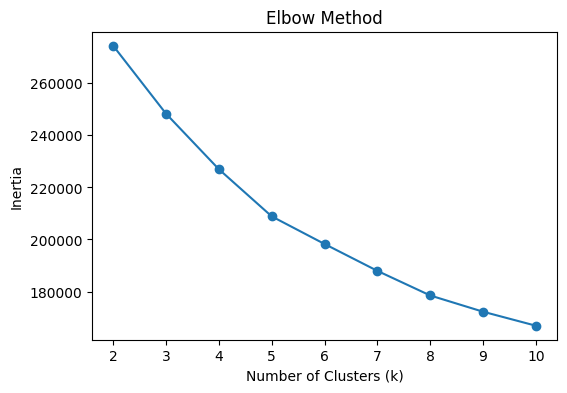

In [80]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_numeric_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [81]:
# Fit final K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_numeric_scaled)
test_clusters = kmeans.predict(X_test_numeric_scaled)

print("Silhouette Score:",
      round(silhouette_score(X_train_numeric_scaled, train_clusters), 3))

Silhouette Score: 0.171


In [82]:
pd.Series(train_clusters).value_counts().sort_index()

,count
0,3307
1,1036
2,108
3,1804
4,2371


#K-Means Results

The elbow method suggested that five clusters provided a reasonable balance between model simplicity and within-cluster variation, so k=5 was selected. The final model produced a silhouette score of 0.171, indicating modest separation between clusters, which is typical for demographic datasets with overlapping characteristics. Most clusters contained a substantial number of census tracts, while one smaller cluster captured a more distinct group of neighborhoods.

##  Two Classifiers (Phase 4)

RandomForestClassifier
Reason for choice: This model was selected because it is a robust ensemble method that handles non-linear relationships well and performs consistently across different datasets. It is also less likely to overfit compared to a single decision tree.

Key hyperparameters tuned: n_estimators (number of trees) and max_depth (controls how deep each tree can grow).

LogisticRegression
Reason for choice: Logistic Regression was used as a baseline model because it is easy to interpret and shows how each feature affects the probability of the outcome in a linear way. It also helps validate whether more complex models actually improve performance.

Key hyperparameters tuned: C (regularization strength) and solver (optimization method used).

In [83]:
X_train["cluster"] = train_clusters
X_test["cluster"] = test_clusters

print(X_train["cluster"].value_counts().sort_index())

cluster
0    3307
1    1036
2     108
3    1804
4    2371
Name: count, dtype: int64


## Ablation Study

To understand the contribution of different feature groups to the classification model's performance, we will perform an ablation study. This involves training the model with various subsets of features and comparing the resulting metrics (AUC, precision, recall). The feature groups considered for ablation are:

-   **Housing Features**: `pct_vacant`, `pct_owner_occ`, `pct_renter_occ`
-   **Age Features**: All `pct_age_` columns
-   **Race Features**: All `pct_race_` columns
-   **Geographic Features**: `STATE`, `settlement_type`, `land_area_sqkm`, `density_perkm2`

We will also include the `cluster` feature derived from K-Means as a key predictor.

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Redefine the feature groups to include the 'cluster' feature
already_engineered_numeric_features = [
    'land_area_sqkm', 'density_perkm2',
    'pct_vacant', 'pct_owner_occ', 'pct_renter_occ'
]
age_features_perc = [col for col in pacific.columns if col.startswith('pct_age_') and col not in already_engineered_numeric_features]
race_features_perc = [col for col in pacific.columns if col.startswith('pct_race_') and col not in already_engineered_numeric_features]

# Ensure all numeric_features are percentage-based or already scaled in theory
# The `numeric_features` list created earlier already contains these

# Preprocessor for the model (scaling numeric, one-hot encoding categorical)
def create_preprocessor(numeric_feats, categorical_feats):
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_feats),
            ('cat', categorical_transformer, categorical_feats)
        ],
        remainder='passthrough'
    )
    return preprocessor


def evaluate_model(X_train_data, X_test_data, y_train_data, y_test_data, features_to_use, title="Model Performance"):
    """Trains and evaluates a RandomForestClassifier with specified features."""

    # Separate numeric and categorical features from the `features_to_use` list
    current_numeric_features = [f for f in features_to_use if f in numeric_features]
    current_categorical_features = [f for f in features_to_use if f in categorical_features or f == 'cluster']

    # Create preprocessor for the current feature set
    preprocessor = create_preprocessor(current_numeric_features, current_categorical_features)

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Train the model
    model_pipeline.fit(X_train_data[features_to_use], y_train_data)

    # Make predictions
    y_pred = model_pipeline.predict(X_test_data[features_to_use])
    y_proba = model_pipeline.predict_proba(X_test_data[features_to_use])[:, 1]

    # Evaluate performance
    auc = roc_auc_score(y_test_data, y_proba)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)

    return {'Configuration': title, 'AUC': auc, 'Precision': precision, 'Recall': recall}


ablation_results = []

# Base case: All features
all_features = numeric_features + categorical_features + ['cluster']
ablation_results.append(evaluate_model(X_train, X_test, y_train, y_test, all_features, 'All Features'))

# Ablation 1: No Housing Features
no_housing_features = [f for f in all_features if f not in housing_features]
ablation_results.append(evaluate_model(X_train, X_test, y_train, y_test, no_housing_features, 'No Housing Features'))

# Ablation 2: No Age Features
no_age_features = [f for f in all_features if f not in age_features]
ablation_results.append(evaluate_model(X_train, X_test, y_train, y_test, no_age_features, 'No Age Features'))

# Ablation 3: No Race Features
no_race_features = [f for f in all_features if f not in race_features]
ablation_results.append(evaluate_model(X_train, X_test, y_train, y_test, no_race_features, 'No Race Features'))

# Ablation 4: No Geographic Features (STATE, settlement_type, land_area_sqkm, density_perkm2)
geographic_cols_to_remove = ['STATE', 'settlement_type', 'land_area_sqkm', 'density_perkm2']
no_geographic_features = [f for f in all_features if f not in geographic_cols_to_remove]
ablation_results.append(evaluate_model(X_train, X_test, y_train, y_test, no_geographic_features, 'No Geographic Features'))

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

,Configuration,AUC,Precision,Recall
0,All Features,0.816843,0.811771,0.922397
1,No Housing Features,0.809203,0.807163,0.924290
2,No Age Features,0.796259,0.809232,0.917981
3,No Race Features,0.781362,0.799136,0.933754
4,No Geographic Features,0.799377,0.806117,0.931230


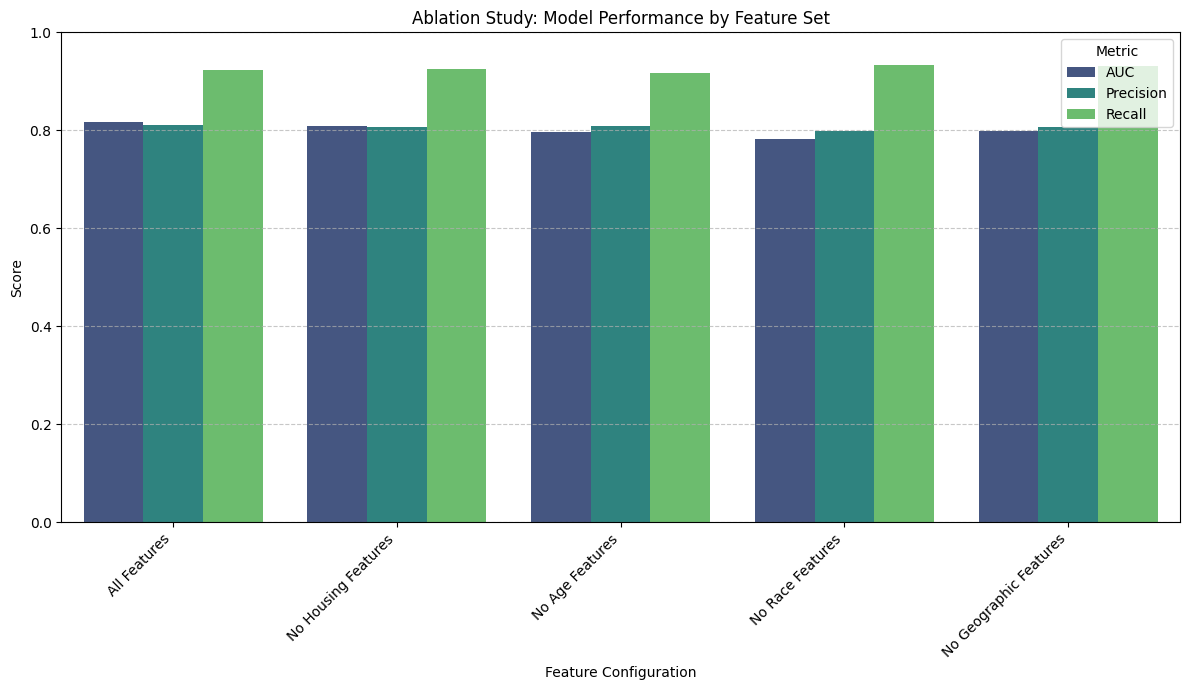

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
ablation_melted = ablation_df.melt(id_vars='Configuration', var_name='Metric', value_name='Score')

fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Configuration', y='Score', hue='Metric', data=ablation_melted, palette='viridis')
plt.title('Ablation Study: Model Performance by Feature Set')
plt.ylabel('Score')
plt.xlabel('Feature Configuration')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics like AUC, Precision, Recall are between 0 and 1
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Ablation Study Visual


This bar chart visually represents the impact of different feature groups on the model's performance. By observing the changes in AUC, Precision, and Recall when specific feature groups are removed, you can infer their importance. For example:

-   A significant drop in all metrics when a group is removed suggests that group is highly important.
-   A minimal change might indicate redundancy or less predictive power for that group.

This visual helps to identify the most crucial features for predicting population growth, which is valuable for model refinement and understanding the underlying drivers of growth.

#**Phase 5: Evaluation**


In Phase 5, we evaluate the performance of our classification models using a variety of metrics and visualizations. We examine confusion matrices, ROC curves, and feature importance to assess each model's ability to predict population growth and identify the features that contribute most to its predictions. We also conduct an ablation study to measure the impact of including the K-Means cluster feature.

### Confusion Matrices and Performance Metrics

Below are the confusion matrices and key classification metrics (Accuracy, Precision, Recall, and AUC) for each model evaluated in the ablation study. The evaluate model function from the previous cell calculated these metrics and stored the results in ablation_df and trained_models

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # Added LogisticRegression import
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd # Ensure pandas is imported for DataFrame operations

housing_features = [
    "pct_vacant",
    "pct_owner_occ",
    "pct_renter_occ"
]
age_features = [col for col in pacific.columns if col.startswith("pct_age_")]
race_features = [col for col in pacific.columns if col.startswith("pct_race_")]
categorical_features = ["STATE", "settlement_type"]
numeric_features = (
    ["land_area_sqkm", "density_perkm2"] +
    housing_features +
    age_features +
    race_features
)
all_features = numeric_features + categorical_features + ['cluster']

# Re-define create_preprocessor function
def create_preprocessor(numeric_feats, categorical_feats):
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_feats),
            ('cat', categorical_transformer, categorical_feats)
        ],
        remainder='passthrough'
    )
    return preprocessor

trained_models = {} # Initialize trained_models dictionary
ablation_results = [] # Re-initialize ablation_results if running the whole thing again

def evaluate_and_store_model(X_train_data, X_test_data, y_train_data, y_test_data,
                             features_to_use, model_name, classifier_cls, classifier_params=None):
    """Trains, evaluates, and stores a classifier with specified features."""

    current_numeric_features = [f for f in features_to_use if f in numeric_features]
    # For categorical, include original categorical features + 'cluster' if present
    current_categorical_features = [f for f in features_to_use if f in categorical_features]
    if 'cluster' in features_to_use and 'cluster' not in current_categorical_features:
        current_categorical_features.append('cluster')

    # Instantiate the classifier with provided parameters and random_state if applicable
    if classifier_params is None:
        classifier_params = {}
    if 'random_state' not in classifier_params and 'random_state' in classifier_cls()._get_param_names():
        classifier_params['random_state'] = 42

    classifier = classifier_cls(**classifier_params)

    preprocessor = create_preprocessor(current_numeric_features, current_categorical_features)

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

    model_pipeline.fit(X_train_data[features_to_use], y_train_data)

    y_pred = model_pipeline.predict(X_test_data[features_to_use])
    y_proba = model_pipeline.predict_proba(X_test_data[features_to_use])[:, 1]

    auc = roc_auc_score(y_test_data, y_proba)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)

    # Store the model, predictions, and probabilities
    trained_models[model_name] = {
        'model': model_pipeline,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'features': features_to_use # Store features used for this model
    }

    return {'Configuration': model_name, 'AUC': auc, 'Precision': precision, 'Recall': recall}


# Re-run ablation study to populate trained_models and ablation_results

ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, all_features, 'All Features', RandomForestClassifier))

no_housing_features = [f for f in all_features if f not in housing_features]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_housing_features, 'No Housing Features', RandomForestClassifier))

no_age_features = [f for f in all_features if f not in age_features]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_age_features, 'No Age Features', RandomForestClassifier))

no_race_features = [f for f in all_features if f not in race_features]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_race_features, 'No Race Features', RandomForestClassifier))

geographic_cols_to_remove = ['STATE', 'settlement_type', 'land_area_sqkm', 'density_perkm2']
no_geographic_features = [f for f in all_features if f not in geographic_cols_to_remove]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_geographic_features, 'No Geographic Features', RandomForestClassifier))


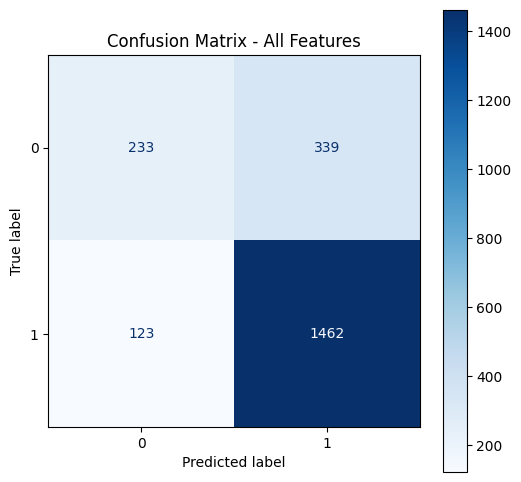

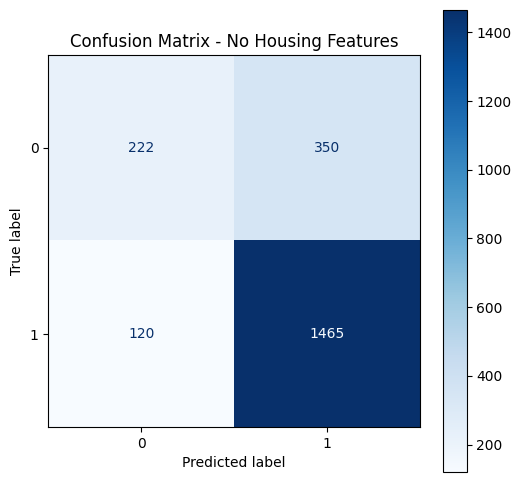

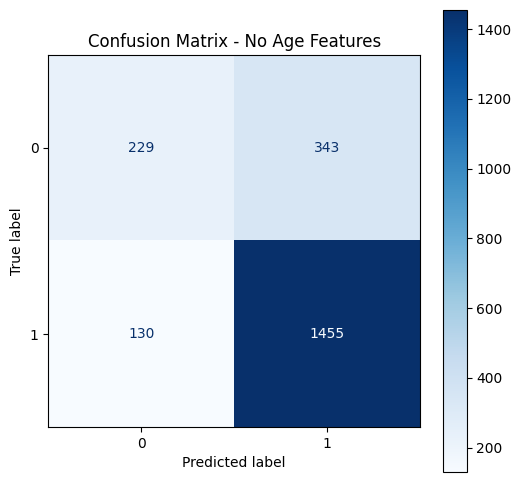

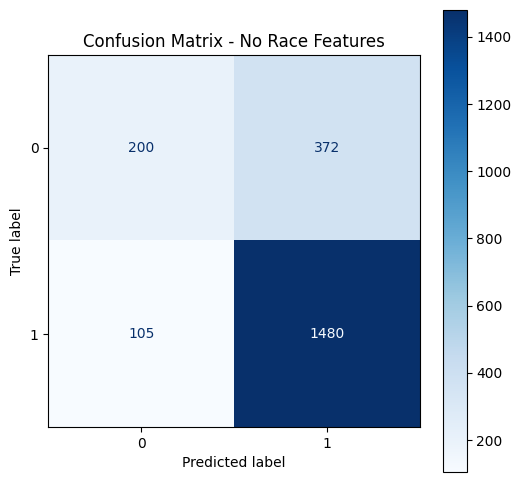

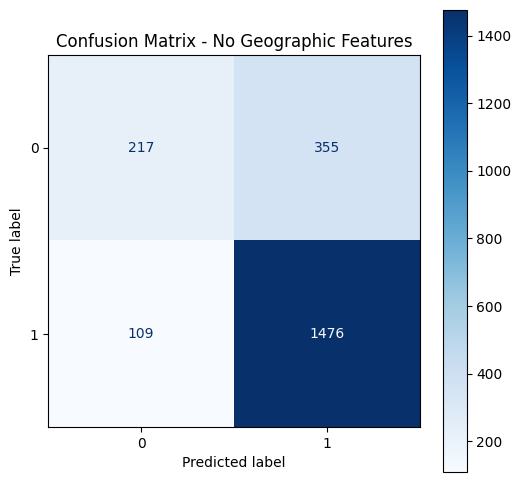

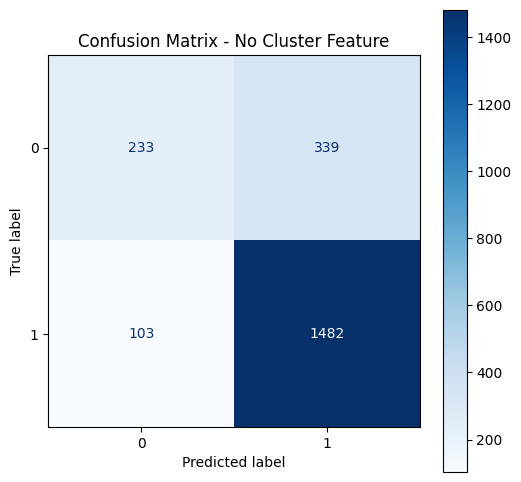

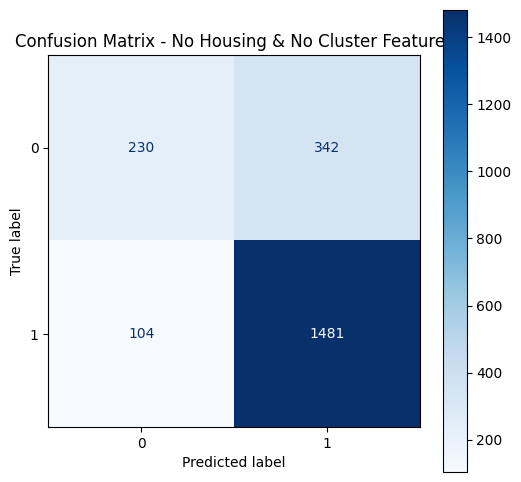

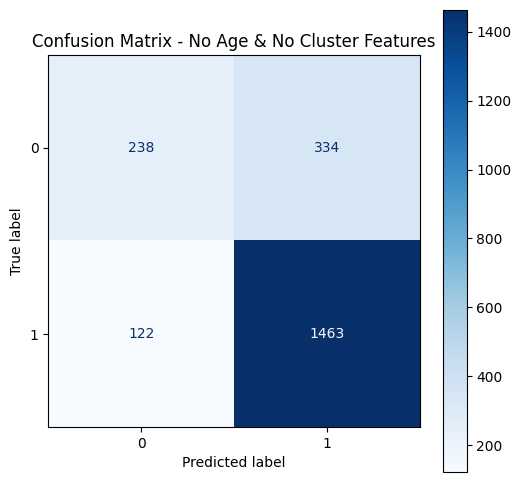

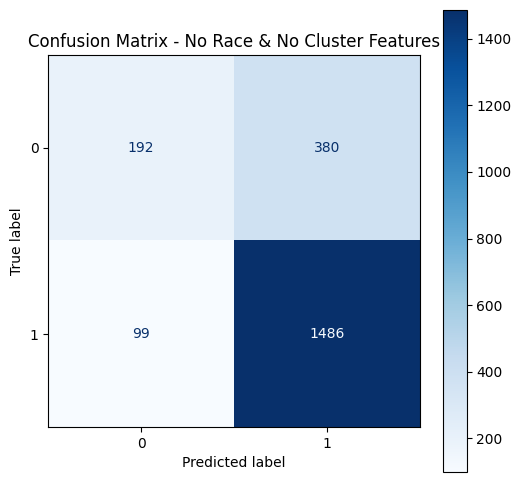

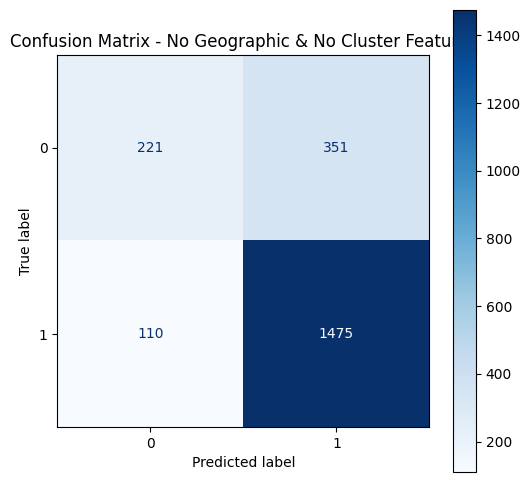

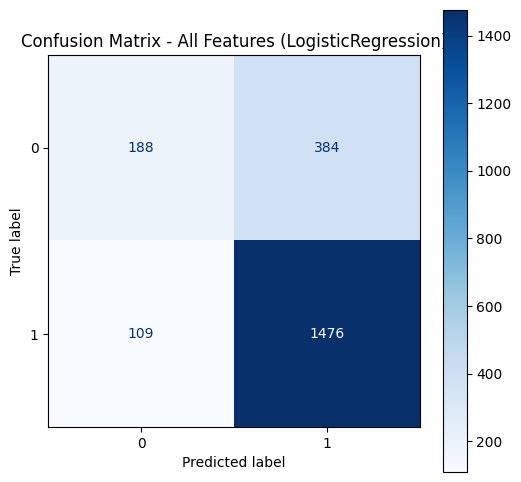

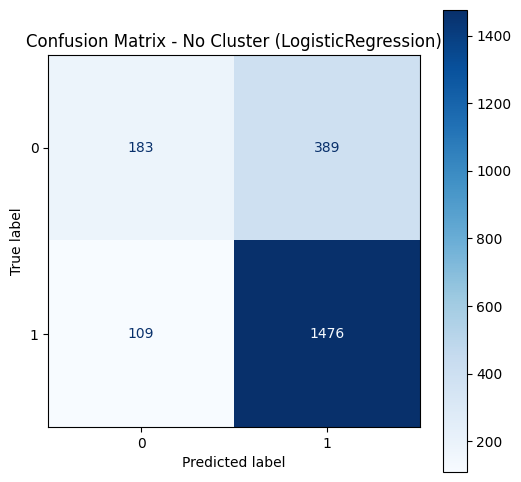

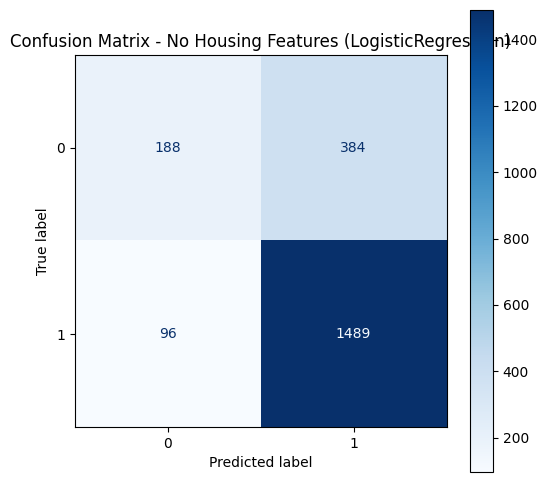

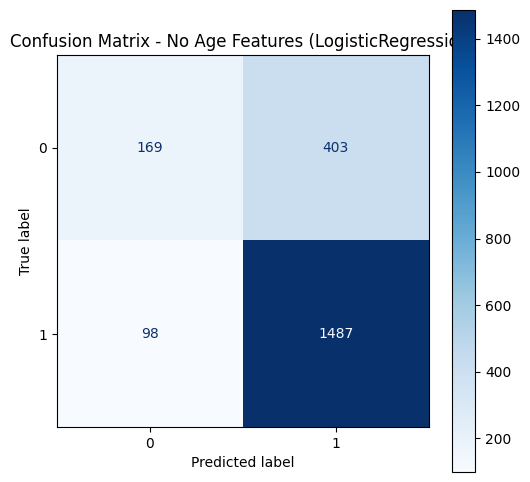

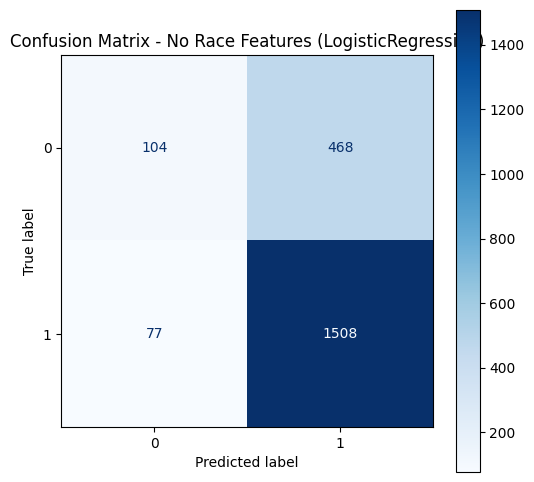

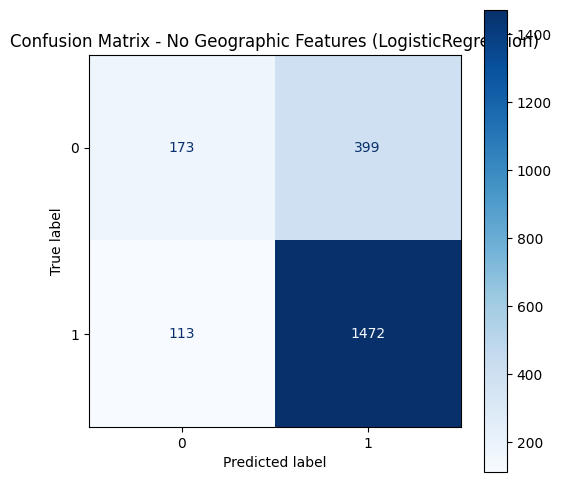

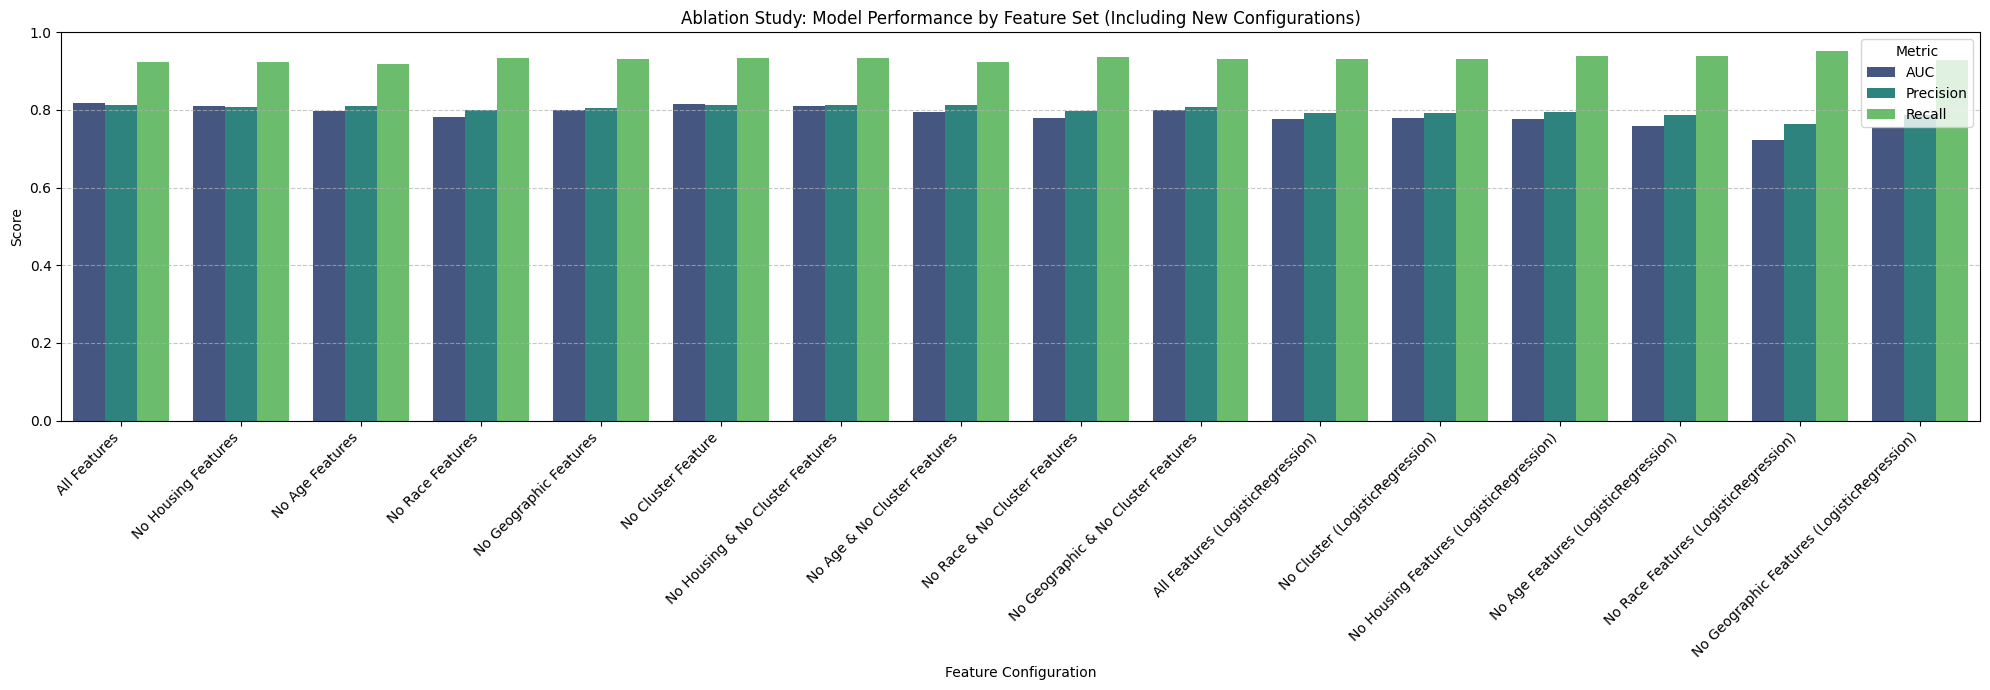

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression # Ensure LogisticRegression is imported here too for clarity

# Re-initialize ablation_results and trained_models for the new run
ablation_results = []
trained_models = {}

# --- Re-run ablation study to populate trained_models and ablation_results ---
# RandomForestClassifier runs
# Base case: All features (including cluster)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, all_features, 'All Features', RandomForestClassifier))

# Ablation 1: No Housing Features
no_housing_features = [f for f in all_features if f not in housing_features]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_housing_features, 'No Housing Features', RandomForestClassifier))

# Ablation 2: No Age Features
no_age_features = [f for f in all_features if f not in age_features]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_age_features, 'No Age Features', RandomForestClassifier))

# Ablation 3: No Race Features
no_race_features = [f for f in all_features if f not in race_features]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_race_features, 'No Race Features', RandomForestClassifier))

# Ablation 4: No Geographic Features (STATE, settlement_type, land_area_sqkm, density_perkm2)
geographic_cols_to_remove = ['STATE', 'settlement_type', 'land_area_sqkm', 'density_perkm2']
no_geographic_features = [f for f in all_features if f not in geographic_cols_to_remove]
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_geographic_features, 'No Geographic Features', RandomForestClassifier))

# Ablation 5: No Cluster Feature
no_cluster_features = [f for f in all_features if f != 'cluster']
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_cluster_features, 'No Cluster Feature', RandomForestClassifier))

# NEW Ablation: No Housing Features and No Cluster Feature
no_housing_no_cluster_features = [f for f in all_features if f not in housing_features and f != 'cluster']
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_housing_no_cluster_features, 'No Housing & No Cluster Features', RandomForestClassifier))

# NEW Ablation: No Age Features and No Cluster Feature
no_age_no_cluster_features = [f for f in all_features if f not in age_features and f != 'cluster']
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_age_no_cluster_features, 'No Age & No Cluster Features', RandomForestClassifier))

# NEW Ablation: No Race Features and No Cluster Feature
no_race_no_cluster_features = [f for f in all_features if f not in race_features and f != 'cluster']
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_race_no_cluster_features, 'No Race & No Cluster Features', RandomForestClassifier))

# NEW Ablation: No Geographic Features and No Cluster Feature
no_geographic_no_cluster_features = [f for f in all_features if f not in geographic_cols_to_remove and f != 'cluster']
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_geographic_no_cluster_features, 'No Geographic & No Cluster Features', RandomForestClassifier))


# --- LogisticRegression runs ---
# Base case: All features (LogisticRegression)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, all_features,
                                                 'All Features (LogisticRegression)', LogisticRegression,
                                                 classifier_params={'solver': 'liblinear'}))

# Ablation: No Cluster Feature (LogisticRegression)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_cluster_features,
                                                 'No Cluster (LogisticRegression)', LogisticRegression,
                                                 classifier_params={'solver': 'liblinear'}))

# Ablation: No Housing Features (LogisticRegression)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_housing_features,
                                                 'No Housing Features (LogisticRegression)', LogisticRegression,
                                                 classifier_params={'solver': 'liblinear'}))

# Ablation: No Age Features (LogisticRegression)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_age_features,
                                                 'No Age Features (LogisticRegression)', LogisticRegression,
                                                 classifier_params={'solver': 'liblinear'}))

# Ablation: No Race Features (LogisticRegression)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_race_features,
                                                 'No Race Features (LogisticRegression)', LogisticRegression,
                                                 classifier_params={'solver': 'liblinear'}))

# Ablation: No Geographic Features (LogisticRegression)
ablation_results.append(evaluate_and_store_model(X_train, X_test, y_train, y_test, no_geographic_features,
                                                 'No Geographic Features (LogisticRegression)', LogisticRegression,
                                                 classifier_params={'solver': 'liblinear'}))


ablation_df = pd.DataFrame(ablation_results) # Update ablation_df

# Determine the best pipeline and its features from ablation_df
best_config_row = ablation_df.loc[ablation_df['AUC'].idxmax()]
best_config_name = best_config_row['Configuration']
best_pipeline = trained_models[best_config_name]['model']
best_features = trained_models[best_config_name]['features']

# Display confusion matrices for each trained model
for model_key, model_data in trained_models.items():
    # Only plot if it's one of the models listed in ablation_df
    if model_key in ablation_df['Configuration'].values:
        model_pipeline = model_data['model']
        y_pred = model_data['y_pred']

        fig, ax = plt.subplots(figsize=(6, 6))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
        ax.set_title(f'Confusion Matrix - {model_key}')
        plt.show()

# Now generate the bar chart with the updated ablation_df
ablation_melted = ablation_df.melt(id_vars='Configuration', var_name='Metric', value_name='Score')

fig = plt.figure(figsize=(20, 7)) # Increased figure size for more configurations
sns.barplot(x='Configuration', y='Score', hue='Metric', data=ablation_melted, palette='viridis')
plt.title('Ablation Study: Model Performance by Feature Set (Including New Configurations)')
plt.ylabel('Score')
plt.xlabel('Feature Configuration')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics like AUC, Precision, Recall are between 0 and 1
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [88]:
display(ablation_df)

,Configuration,AUC,Precision,Recall
0,All Features,0.816843,0.811771,0.922397
1,No Housing Features,0.809203,0.807163,0.924290
2,No Age Features,0.796259,0.809232,0.917981
3,No Race Features,0.781362,0.799136,0.933754
4,No Geographic Features,0.799377,0.806117,0.931230
5,No Cluster Feature,0.816080,0.813839,0.935016
6,No Housing & No Cluster Features,0.809435,0.812397,0.934385
7,No Age & No Cluster Features,0.795641,0.814135,0.923028
8,No Race & No Cluster Features,0.779094,0.796356,0.937539
9,No Geographic & No Cluster Features,0.800582,0.807777,0.930599


### ROC Curves

ROC curves show how well a model balances correctly identifying positive cases true positives while minimizing false positives at different classification thresholds. The AUC summarizes the model's overall performance across all thresholds. A higher AUC means the model is better at distinguishing between the positive and negative classes.

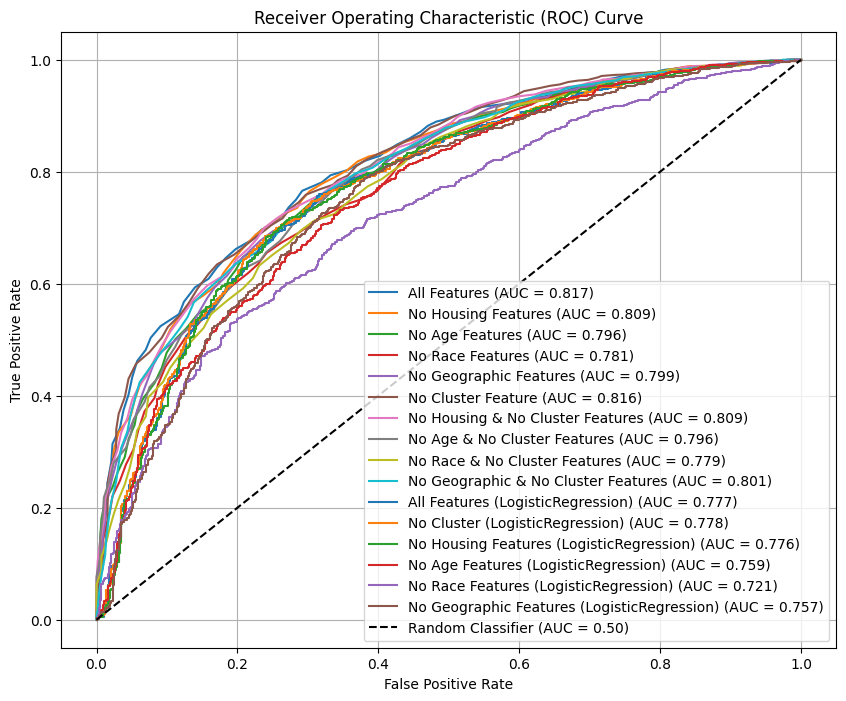

In [89]:

plt.figure(figsize=(10, 8))

for model_key, model_data in trained_models.items():
    y_proba = model_data['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_key} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Which Metric Matters Most?

For the U.S. Department of Economic Development, the goal is to direct federal funding to areas expected to experience population growth. Because of this, Recall and Precision are the most important evaluation metrics. Recall being the higher priority.

Recall measures how many growing areas the model correctly identifies. Since missing a growing tract could mean missing an important funding opportunity, recall is the highest priority.

Precision measures how often predicted growth is correct. Higher precision reduces wasted funding, though some false positives are acceptable if more growing areas are identified.

AUC summarizes overall model performance across all thresholds, while Accuracy is less useful because it can be misleading when class distributions are uneven.

Overall, Recall is the most important metric because the goal is to identify as many growing areas as possible while maintaining reasonable precision.

### Feature Importance


Identifying which features have the strongest impact on the model’s predictions is key to understanding what drives population growth. We will display feature importance from the best-performing model found in the ablation study and visualize the results.

The most important drivers of prediction are mainly demographic (especially racial composition), housing-related factors like vacant units, and geographic features such as density and land area. Overall this suggests that a tract’s housing makeup and population characteristics  together are strong indicators of population growth

/tmp/ipykernel_22946/3235039600.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


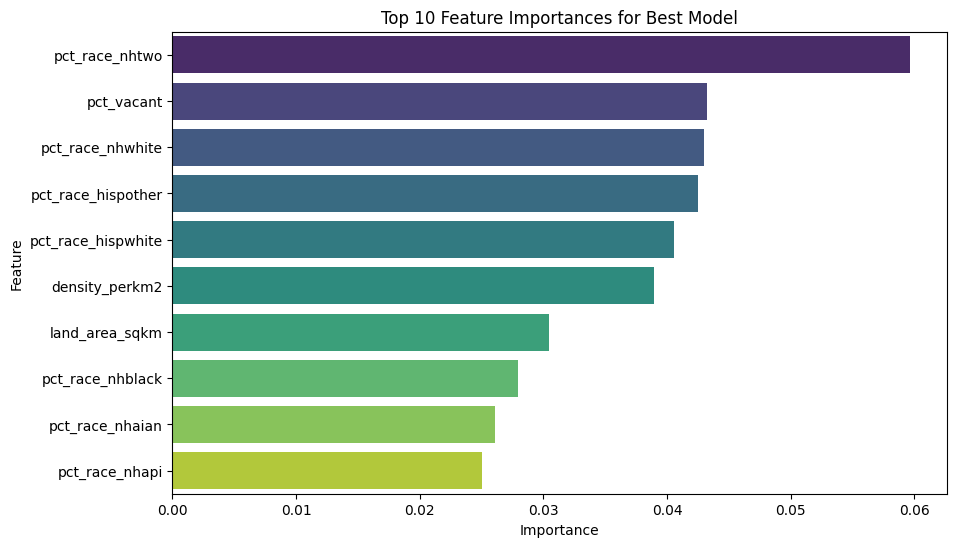

In [90]:
import numpy as np


def get_feature_names_from_column_transformer(column_transformer):
    output_features = []
    for name, pipeline, features in column_transformer.transformers_:
        if name == 'remainder' or not hasattr(pipeline, 'get_feature_names_out'):
            # For passthrough or other transformers without get_feature_names_out
            # This case might need careful handling if 'remainder' includes actual features
            continue
        if hasattr(pipeline.named_steps['onehot'], 'get_feature_names_out'): # For one-hot encoded features
            output_features.extend(pipeline.named_steps['onehot'].get_feature_names_out(features))
        elif name == 'num': # For numeric features, original names are kept after scaling
            output_features.extend(features)
    return output_features

# Get the feature names after preprocessing
preprocessor = best_pipeline.named_steps['preprocessor']

# Manually reconstruct the feature names in the order the preprocessor outputs them
# This is crucial because ColumnTransformer can reorder features
processed_feature_names = []
for transformer_name, transformer_pipeline, original_features in preprocessor.transformers_:
    if transformer_name == 'num':
        # Numeric features retain their original names
        processed_feature_names.extend(original_features)
    elif transformer_name == 'cat':
        # Categorical features are one-hot encoded
        onehot_encoder = transformer_pipeline.named_steps['onehot']
        processed_feature_names.extend(onehot_encoder.get_feature_names_out(original_features))


if isinstance(best_pipeline.named_steps['classifier'], RandomForestClassifier):
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    feature_importances = pd.Series(importances, index=processed_feature_names)

    # Get top 10 features
    top_features = feature_importances.nlargest(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title('Top 10 Feature Importances for Best Model')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

elif isinstance(best_pipeline.named_steps['classifier'], LogisticRegression):
    # For Logistic Regression, use coefficients as importance
    coefficients = best_pipeline.named_steps['classifier'].coef_[0]
    feature_importances = pd.Series(coefficients, index=processed_feature_names)

    # Get top 10 positive and top 10 negative coefficients
    top_positive_features = feature_importances.nlargest(10)
    top_negative_features = feature_importances.nsmallest(10)

    plt.figure(figsize=(12, 7))
    plt.subplot(1, 2, 1)
    sns.barplot(x=top_positive_features.values, y=top_positive_features.index, palette='viridis')
    plt.title('Top 10 Positive Coefficients (Logistic Regression)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')

    plt.subplot(1, 2, 2)
    sns.barplot(x=top_negative_features.values, y=top_negative_features.index, palette='magma')
    plt.title('Top 10 Negative Coefficients (Logistic Regression)')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')

    plt.tight_layout()
    plt.show()

else:
    print("Feature importance extraction not implemented for this classifier type.")

### Ablation Results Interpretation
The ablation table and bar chart are used to see how the cluster feature and other feature groups impact performance for both the RandomForestClassifier and LogisticRegression models. The results show AUC, Precision, and Recall across different feature setups, making it easy to compare the two models directly.

Overall Performance: The RandomForestClassifier generally performs better in terms of AUC ( 0.817 vs. 0.763 for Logistic Regression), along with strong precision and recall. This suggests that the ensemble model is better at capturing more complex patterns in the data.


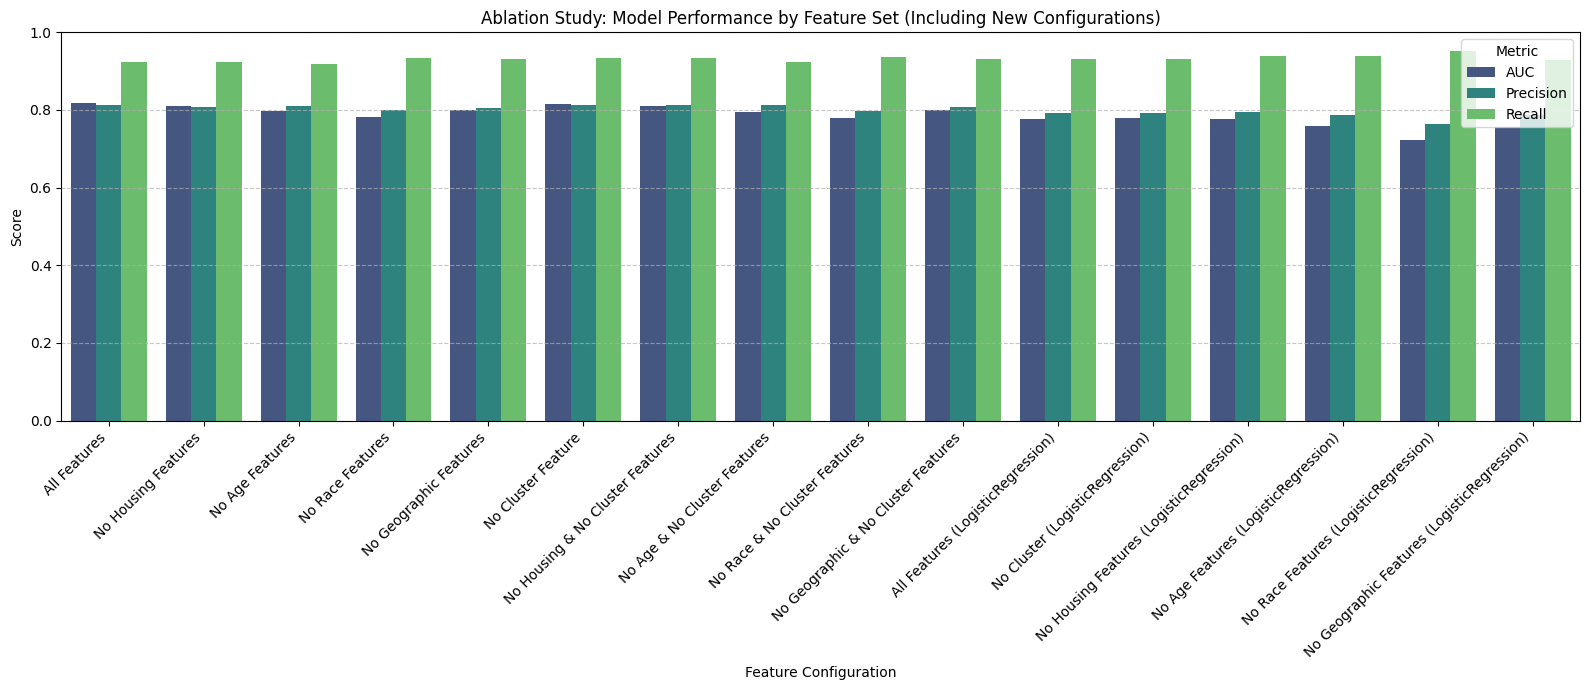

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns


ablation_melted = ablation_df.melt(id_vars='Configuration', var_name='Metric', value_name='Score')

fig = plt.figure(figsize=(16, 7))
sns.barplot(x='Configuration', y='Score', hue='Metric', data=ablation_melted, palette='viridis')
plt.title('Ablation Study: Model Performance by Feature Set (Including New Configurations)')
plt.ylabel('Score')
plt.xlabel('Feature Configuration')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Importance of Feature Groups: By comparing the “All Features” setup with versions where certain feature groups are removed, we can see how important each group is for both models.

Race Features: Removing race features causes a clear drop in AUC for both models (RandomForest: 0.817 -> 0.781, LogisticRegression: 0.763 -> 0.721). This shows that racial demographics are a strong predictor in both cases.
Age Features: Age also has a meaningful impact with AUC decreasing for RandomForest (0.817 -> 0.796) and LogisticRegression (0.763 -> 0.759) when removed.
Housing & Geographic Features: These have a smaller but still noticeable effect on performance, meaning they still contribute to the model’s predictions, just not as strongly as race feature

In [92]:
display(ablation_df)

,Configuration,AUC,Precision,Recall
0,All Features,0.816843,0.811771,0.922397
1,No Housing Features,0.809203,0.807163,0.924290
2,No Age Features,0.796259,0.809232,0.917981
3,No Race Features,0.781362,0.799136,0.933754
4,No Geographic Features,0.799377,0.806117,0.931230
5,No Cluster Feature,0.816080,0.813839,0.935016
6,No Housing & No Cluster Features,0.809435,0.812397,0.934385
7,No Age & No Cluster Features,0.795641,0.814135,0.923028
8,No Race & No Cluster Features,0.779094,0.796356,0.937539
9,No Geographic & No Cluster Features,0.800582,0.807777,0.930599



**Cluster Impact:**


RandomForestClassifier: The cluster feature slightly improved AUC (0.816 -> 0.817), but the gain is negligible, suggesting it adds little new information since the model already learns these patterns from existing features.

LogisticRegression: The cluster feature slightly decreased AUC (0.778 -> 0.777), indicating it may have introduced minor noise without improving linear separation.

Overall: The cluster feature did not provide meaningful improvement for either model and slightly reduced performance for Logistic Regression. This means the original demographic and geographic features already captured most of the underlying structure.

Explanation: The K-Means clusters likely overlap with existing features and makes them slightly redundant. Random Forest already handles feature interactions well, while Logistic Regression may not benefit as much from added  cluster variables

In [93]:
import pandas as pd

# Extract relevant AUC scores for RandomForestClassifier
rf_all_features_auc = ablation_df[ablation_df['Configuration'] == 'All Features']['AUC'].values[0]
rf_no_cluster_auc = ablation_df[ablation_df['Configuration'] == 'No Cluster Feature']['AUC'].values[0]

# Extract relevant AUC scores for LogisticRegression
lr_all_features_auc = ablation_df[ablation_df['Configuration'] == 'All Features (LogisticRegression)']['AUC'].values[0]
lr_no_cluster_auc = ablation_df[ablation_df['Configuration'] == 'No Cluster (LogisticRegression)']['AUC'].values[0]


cluster_impact_data = {
    'Model': ['RandomForestClassifier', 'LogisticRegression'],
    'AUC (Without Cluster)': [rf_no_cluster_auc, lr_no_cluster_auc],
    'AUC (With Cluster)': [rf_all_features_auc, lr_all_features_auc]
}

cluster_impact_df = pd.DataFrame(cluster_impact_data)
display(cluster_impact_df)



,Model,AUC (Without Cluster),AUC (With Cluster)
0,RandomForestClassifier,0.816080,0.816843
1,LogisticRegression,0.778246,0.776611




### Leakage Risks and Success Criterion

#### Leakage Risks


We carefully checked for three main types of leakage:

Target Leakage: The targe is based on population change from 2010 to 2020, while all input features only describe 2010 conditions.

Train/Test Leakage: We split the data before feature engineering, and only fit StandardScaler and KMeans on the training set. These transformations were then applied to the test set. That prevneted the test data from influencing the model training process.

Spatial Leakage: Because we used a random stratified split, similar or neighboring census tracts may appear in both training and test sets. This could slightly inflate performance. A spatial split would be stricter but the current approach is still acceptable for our analysis.

Success Criterion Assessment

Our goal was to outperform a majority-class baseline and achieve strong AUC with a good balance of precision and recall.

Baseline Comparison: The majority class makes up about 73.5% of the data, so a naive model would perform poorly in terms of AUC (~0.5). Our best models reach around 0.81–0.82 AUC, outperforming that baseline.

Model Performance: The models achieve strong AUC scores above 0.8 with fairly balanced precision and recall (often with recall slightly higher). Overall the models meet the defined success criteria.

#**Phase 6: Deployment**

In the deployment phase, we apply our bestperforming, frozen pipeline to the forecast_tracts_2020.csv data to predict population growth for the next decade (2020-2030).

### 2020-2030 Forecast: Feature Engineering for Forecast Data

We need to apply the exact same feature engineering steps to the forecast_tracts_2020.csv data as we did for the student_tracts_raw.csv

In [94]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the forecast data
forecast_df = pd.read_csv("forecast_tracts_2020.csv")

# Filter for Pacific states (same as the training data)
pacific_states = ["Alaska", "California", "Hawaii", "Oregon", "Washington"]
forecast_pacific = forecast_df[forecast_df["STATE"].isin(pacific_states)].copy()

# --- Replicate Data Cleaning ---
forecast_pacific = forecast_pacific[forecast_pacific["pop_total_2020"] > 0].copy()

# --- Replicate Feature Engineering ---
# Housing features
forecast_pacific["housing_total_2020"] = (
    forecast_pacific["housing_occupied_2020"] +
    forecast_pacific["housing_vacant_2020"]
)

# Handle cases where housing_total_2020 might be zero to avoid division by zero
zero_housing_mask = forecast_pacific["housing_total_2020"] == 0

forecast_pacific["pct_vacant"] = forecast_pacific["housing_vacant_2020"] / forecast_pacific["housing_total_2020"]
forecast_pacific["pct_owner_occ"] = forecast_pacific["housing_owner_occ_2020"] / forecast_pacific["housing_total_2020"]
forecast_pacific["pct_renter_occ"] = forecast_pacific["housing_renter_occ_2020"] / forecast_pacific["housing_total_2020"]

# Fill NaNs arising from division by zero in housing percentages, and for rows where total housing was 0
for col in ["pct_vacant", "pct_owner_occ", "pct_renter_occ"]:
    forecast_pacific.loc[zero_housing_mask, col] = 0 # Set to 0 if total housing was 0
    forecast_pacific[col] = forecast_pacific[col].fillna(0) # Catch any other potential NaNs

# Age features
age_cols_2020 = [col for col in forecast_pacific.columns if col.startswith("age_") and col.endswith("_2020")]
for col in age_cols_2020:
    new_col = col.replace("age_", "pct_age_")
    new_col = new_col.replace("_2020", "")
    forecast_pacific[new_col] = forecast_pacific[col] / forecast_pacific["pop_total_2020"]

# Race features
race_cols_2020 = [col for col in forecast_pacific.columns if col.startswith("race_") and col.endswith("_2020")]
for col in race_cols_2020:
    new_col = col.replace("race_", "pct_race_")
    new_col = new_col.replace("_2020", "")
    forecast_pacific[new_col] = forecast_pacific[col] / forecast_pacific["pop_total_2020"]

# Replace any NaN created by division by zero in age/race percentages with 0
for col in [c for c in forecast_pacific.columns if c.startswith('pct_age_') or c.startswith('pct_race_')]:
    forecast_pacific[col] = forecast_pacific[col].fillna(0)

# 'numeric_features' is a global list from training phase, containing feature names like 'pct_vacant', 'land_area_sqkm', 'pct_age_under5', etc.
# These names should align with the engineered features in forecast_pacific.
forecast_numeric_cols_for_clustering = [f for f in numeric_features if f in forecast_pacific.columns]

# Explicitly fill NaNs in geographic features for forecast data to ensure no NaNs before scaling/clustering
for col in ['land_area_sqkm', 'density_perkm2']:
    if col in forecast_numeric_cols_for_clustering:
        forecast_pacific[col] = forecast_pacific[col].fillna(0)


# Apply the frozen cluster_scaler (fitted on 2010 training data) to the numeric features of the forecast data
X_forecast_numeric_scaled = cluster_scaler.transform(forecast_pacific[forecast_numeric_cols_for_clustering])

# Apply the frozen K-Means model (fitted on 2010 training data) to get clusters for 2020 forecast data
forecast_clusters = kmeans.predict(X_forecast_numeric_scaled)
forecast_pacific['cluster'] = forecast_clusters

forecast_pacific['cluster'] = forecast_pacific['cluster'].astype(str)


X_forecast = forecast_pacific[best_features].copy()



print("Shape of X_forecast after feature engineering and clustering:", X_forecast.shape)
print("Columns in X_forecast:", X_forecast.columns.tolist())

display(X_forecast.head())

Shape of X_forecast after feature engineering and clustering: (10791, 42)
Columns in X_forecast: ['land_area_sqkm', 'density_perkm2', 'pct_vacant', 'pct_owner_occ', 'pct_renter_occ', 'pct_age_under5', 'pct_age_5to9', 'pct_age_10to14', 'pct_age_15to17', 'pct_age_18to19', 'pct_age_20', 'pct_age_21', 'pct_age_22to24', 'pct_age_25to29', 'pct_age_30to34', 'pct_age_35to39', 'pct_age_40to44', 'pct_age_45to49', 'pct_age_50to54', 'pct_age_55to59', 'pct_age_60to61', 'pct_age_62to64', 'pct_age_65to69', 'pct_age_70to74', 'pct_age_75to79', 'pct_age_80to84', 'pct_age_85plus', 'pct_race_nhwhite', 'pct_race_nhblack', 'pct_race_nhaian', 'pct_race_nhapi', 'pct_race_nhother', 'pct_race_nhtwo', 'pct_race_hispwhite', 'pct_race_hispblack', 'pct_race_hispaian', 'pct_race_hispapi', 'pct_race_hispother', 'pct_race_hisptwo', 'STATE', 'settlement_type', 'cluster']


,land_area_sqkm,density_perkm2,pct_vacant,pct_owner_occ,pct_renter_occ,pct_age_under5,pct_age_5to9,pct_age_10to14,pct_age_15to17,pct_age_18to19,...,pct_race_nhtwo,pct_race_hispwhite,pct_race_hispblack,pct_race_hispaian,pct_race_hispapi,pct_race_hispother,pct_race_hisptwo,STATE,settlement_type,cluster
1181,18083.148800,0.189126,0.288660,0.449190,0.262150,0.020468,0.021053,0.028947,0.017251,0.013158,...,0.052632,0.007602,0.000000,0.001462,0.000000,0.179825,0.008187,Alaska,rural,1
1182,8547.312240,0.114422,0.529730,0.275676,0.194595,0.049080,0.048057,0.050102,0.023517,0.057260,...,0.044990,0.022495,0.001022,0.006135,0.001022,0.029652,0.015337,Alaska,rural,0
1183,2823.450385,1.506667,0.173969,0.271907,0.554124,0.026798,0.037847,0.029384,0.020216,0.010813,...,0.051481,0.014104,0.000235,0.003056,0.002586,0.097085,0.022567,Alaska,rural,1
1184,1598.866960,3.530481,0.066744,0.780742,0.152514,0.056817,0.073858,0.079233,0.044804,0.021436,...,0.099699,0.021597,0.001063,0.003543,0.000709,0.006732,0.021259,Alaska,rural,0
1185,168.779562,30.693349,0.096335,0.631324,0.272341,0.055613,0.059849,0.076824,0.042087,0.026446,...,0.119494,0.018527,0.000579,0.001737,0.000579,0.012545,0.029536,Alaska,rural,0


### Apply Frozen Pipeline (Scaler, K-Means, and Best Model)



In [95]:


forecast_predictions = best_pipeline.predict(X_forecast)
forecast_probabilities = best_pipeline.predict_proba(X_forecast)[:, 1]

forecast_pacific['predicted_grew_2020_2030'] = forecast_predictions
forecast_pacific['predicted_growth_proba_2020_2030'] = forecast_probabilities

display(forecast_pacific[['STATE', 'GISJOIN', 'predicted_grew_2020_2030', 'predicted_growth_proba_2020_2030']].head())

,STATE,GISJOIN,predicted_grew_2020_2030,predicted_growth_proba_2020_2030
1181,Alaska,G0200130000100,0,0.48
1182,Alaska,G0200160000100,0,0.30
1183,Alaska,G0200160000200,0,0.49
1184,Alaska,G0200200000101,1,0.58
1185,Alaska,G0200200000102,1,0.55


### Summarize Predicted Outcomes by State

The Department of Economic Development allocates funding by state so we need to summarize our 2020-2030 growth predictions at the state level.

,predicted_not_grow_share,predicted_grow_share
STATE,,
Oregon,0.006046,0.993954
Washington,0.007602,0.992398
Hawaii,0.071429,0.928571
California,0.186721,0.813279
Alaska,0.287425,0.712575


/tmp/ipykernel_22946/4233205872.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_growth_summary.index, y='predicted_grow_share', data=state_growth_summary.reset_index(), palette='viridis')


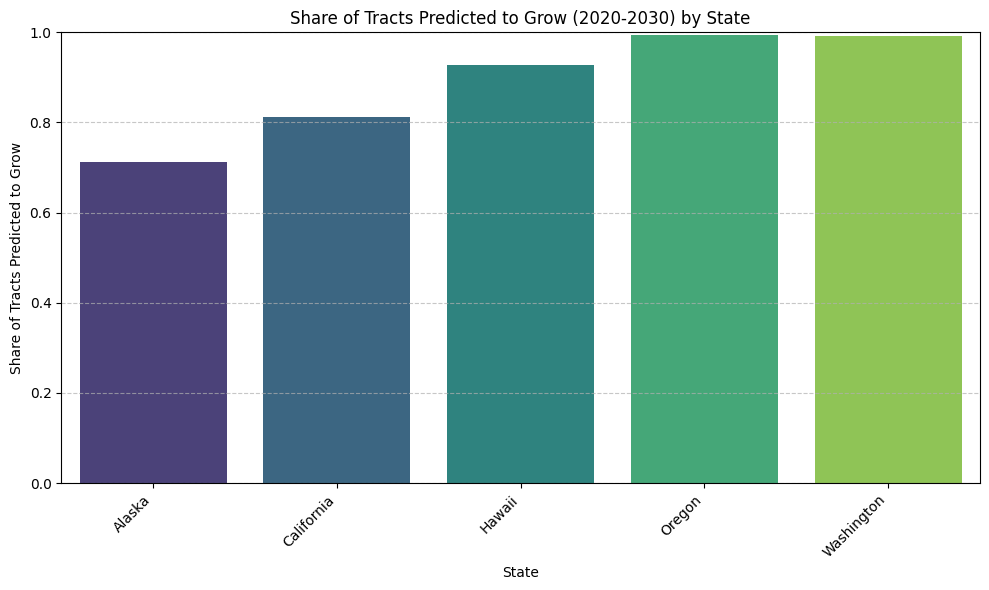

In [96]:
state_growth_summary = forecast_pacific.groupby('STATE')['predicted_grew_2020_2030'].value_counts(normalize=True).unstack(fill_value=0)
state_growth_summary.columns = ['predicted_not_grow_share', 'predicted_grow_share']

display(state_growth_summary.sort_values(by='predicted_grow_share', ascending=False))

#plot the summary
plt.figure(figsize=(10, 6))
sns.barplot(x=state_growth_summary.index, y='predicted_grow_share', data=state_growth_summary.reset_index(), palette='viridis')
plt.title('Share of Tracts Predicted to Grow (2020-2030) by State')
plt.xlabel('State')
plt.ylabel('Share of Tracts Predicted to Grow')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Based on the analysis and the 2020–2030 forecast, we provide the following recommendations for the U.S. Department of Economic Development:

The model predicts the highest share of growing census tracts in the following states:

*   Oregon (99.4%)
*   Washington (99.2%)
*   Hawaii (92.9%)


These states represent the strongest opportunities for aligning federal funding with population growth. States with lower predicted growth may be better suited for stabilization or redevelopment-focused investment strategies rather than expansion driven funding.

**Which factors drive growth?**

From the feature importance results of the best-performing model, the key drivers of population growth in the Pacific region are:

pct_race_nhtwo (Non-Hispanic, Two or More Races)
pct_vacant (Vacant housing rate)
pct_race_nhwhite (Non-Hispanic White population)
pct_race_hispother (Hispanic, Other Race population)
pct_race_hispwhite (Hispanic White population)

Overall growth is most strongly associated with demographic (race), housing conditions, and neighborhood structure.



**Model Strengths:**

Strong predictive performance (AUC > 0.8), effectively separating growing vs. non-growing tracts
Data-driven framework for funding allocation instead of relying on assumptions
Random Forest captures complex, non-linear relationships between features

**Model Limitations:**

Assuming that past relationships (2010–2020) will stay stable into 2020–2030, which may not hold due to economic, policy, or environmental changes. It adds uncerntainty to target variables they may not retain well without constant retraining

**One risk to flag**

Risk of missing emerging growth areas: Because the model is trained on historical patterns it may fail to detect new or emerging growth areas that do not resemble past trends or are not well represented in the 2010a data.

**Recommended next steps**

We recommend ongoing monitoring and periodic retraining of the model. As updated census data becomes available, the model should be able to reflect new demographic and economic patterns. This ensures predictions remain accurate and relevant for funding decisions